# Logical CAPTCHA Benchmark Analysis

Evaluation of reasoning performance of LLMs on synthetic logical CAPTCHA tasks.

Compared strategies:
- Direct answering
- Chain-of-Thought (CoT)
- Self-Consistency

Compared models:
- GPT-5.1
- GPT-4o-mini

In [65]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

In [66]:
result_files = list(Path(".").rglob("results/results_*gpt*.json"))

print("Found result files:")
for f in result_files:
    print(f)

Found result files:
results/results_cot_gpt-4o-mini.json
results/results_self_consistency_gpt-5.1.json
results/results_self_consistency_gpt-4o-mini.json
results/results_cot_gpt-5.1.json
results/results_direct_gpt-5.1.json
results/results_direct_gpt-4o-mini.json


In [67]:
frames = []

for file in result_files:
    with open(file) as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    df["source_file"] = file.name
    frames.append(df)

df = pd.concat(frames, ignore_index=True)

print("Total rows:", len(df))
df.head()

Total rows: 600


,id,task_type,question,ground_truth,model,strategy,temperature,raw_output,parsed_prediction,correct,latency,source_file,self_consistency_runs,all_predictions,all_raw_outputs
0,1,countVowels,Count the vowels in the string: dgfdsfhuipoai,5,gpt-4o-mini,cot,0,"To count the vowels in the string ""dgfdsfhuipo...",5,True,5.489262,results_cot_gpt-4o-mini.json,NaN,NaN,NaN
1,2,countVowels,Count the vowels in the string: oihjsahsaud,5,gpt-4o-mini,cot,0,"To count the vowels in the string ""oihjsahsaud...",5,True,5.248202,results_cot_gpt-4o-mini.json,NaN,NaN,NaN
2,3,countVowels,Count the vowels in the string: aufnbejtkfi,4,gpt-4o-mini,cot,0,"To count the vowels in the string ""aufnbejtkfi...",4,True,4.277215,results_cot_gpt-4o-mini.json,NaN,NaN,NaN
3,4,countVowels,Count the vowels in the string: hkhgfdhybnijg,1,gpt-4o-mini,cot,0,"To count the vowels in the string ""hkhgfdhybni...",1,True,3.988305,results_cot_gpt-4o-mini.json,NaN,NaN,NaN
4,5,countConsonants,Count the Consonants in the string: hgrwopjuia,6,gpt-4o-mini,cot,0,"To count the consonants in the string ""hgrwopj...",6,True,3.998922,results_cot_gpt-4o-mini.json,NaN,NaN,NaN


In [68]:
df.groupby(["model","strategy"]).size()

model        strategy        
gpt-4o-mini  cot                 100
             direct              100
             self_consistency    100
gpt-5.1      cot                 100
             direct              100
             self_consistency    100
dtype: int64

In [69]:
summary = (
    df.groupby(["model","strategy"])
    .agg(
        tasks=("id","count"),
        accuracy=("correct","mean"),
        avg_latency=("latency","mean")
    )
    .reset_index()
)

summary["accuracy"] = summary["accuracy"]*100

summary

,model,strategy,tasks,accuracy,avg_latency
0,gpt-4o-mini,cot,100,72.0,5.056929
1,gpt-4o-mini,direct,100,48.0,1.098557
2,gpt-4o-mini,self_consistency,100,71.0,53.043710
3,gpt-5.1,cot,100,84.0,5.586760
4,gpt-5.1,direct,100,66.0,1.469677
5,gpt-5.1,self_consistency,100,91.0,70.458720


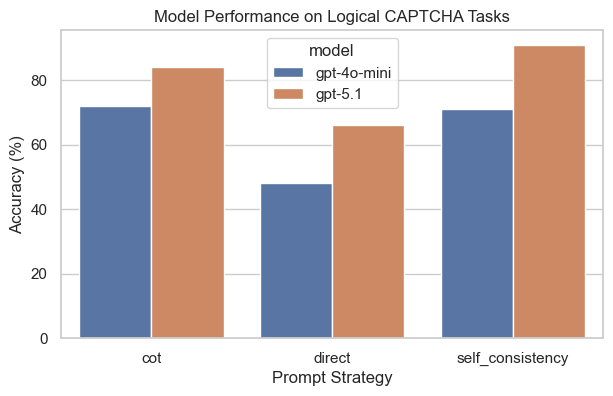

In [70]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=summary,
    x="strategy",
    y="accuracy",
    hue="model"
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Prompt Strategy")
plt.title("Model Performance on Logical CAPTCHA Tasks")

plt.show()

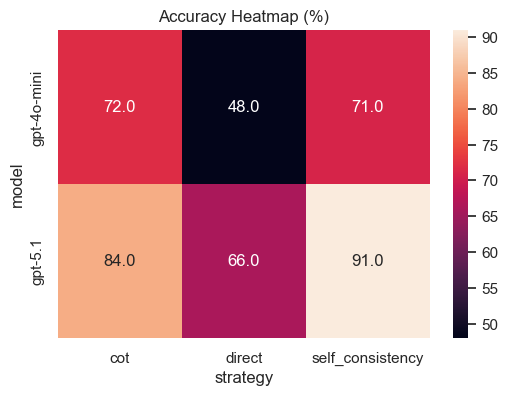

In [71]:
heatmap = df.pivot_table(
    values="correct",
    index="model",
    columns="strategy",
    aggfunc="mean"
)*100

plt.figure(figsize=(6,4))

sns.heatmap(
    heatmap,
    annot=True,
    fmt=".1f"
)

plt.title("Accuracy Heatmap (%)")

plt.show()

In [72]:
errors = df[df["correct"]==False]

print("Number of errors:",len(errors))

errors[["model","strategy","question","ground_truth","parsed_prediction"]].head()

Number of errors: 168


,model,strategy,question,ground_truth,parsed_prediction
7,gpt-4o-mini,cot,Count the Consonants in the string: unfallvers...,12,11
8,gpt-4o-mini,cot,Is the number of characters even in the string...,yes,14
9,gpt-4o-mini,cot,Is the number of characters even in the string...,yes,odd
10,gpt-4o-mini,cot,Is the number of characters even in the string...,yes,even
11,gpt-4o-mini,cot,Is the number of characters even in the string...,no,even


In [73]:
def show_error_examples(n=5):
    sample = errors.sample(n)

    for _,row in sample.iterrows():
        print("--------------------------------------------------")
        print("MODEL:",row["model"])
        print("STRATEGY:",row["strategy"])
        print()
        print("QUESTION:")
        print(row["question"])
        print()
        print("GROUND TRUTH:",row["ground_truth"])
        print("PREDICTION:",row["parsed_prediction"])
        print()
        print("RAW OUTPUT:")
        print(row["raw_output"])
        print()

show_error_examples(5)

--------------------------------------------------
MODEL: gpt-4o-mini
STRATEGY: cot

QUESTION:
(left or right)- I have an image of a giraffe, the feet are pointing to the top right. What direction do I have to turn the image for the giraffe to be right side up the fastest?

GROUND TRUTH: right
PREDICTION: counterclockwise

RAW OUTPUT:
To determine the fastest way to turn the image of the giraffe so that it is right side up, we need to analyze the current orientation of the giraffe's feet.

1. The giraffe's feet are currently pointing to the top right. This means the giraffe is tilted at an angle, likely around 45 degrees clockwise from the upright position.

2. To make the giraffe right side up, we need to rotate it counterclockwise. 

3. If we turn the image 45 degrees counterclockwise, the feet will then point straight down, which is the correct upright position for the giraffe.

4. Therefore, the fastest way to turn the image is to rotate it counterclockwise.

The answer is counterc

In [74]:
sc = df[df["strategy"]=="self_consistency"].copy()

def consistency_ratio(pred_list):
    if not isinstance(pred_list,list):
        return None
    
    counts = pd.Series(pred_list).value_counts()
    return counts.iloc[0]/len(pred_list)

sc["consistency"] = sc["all_predictions"].apply(consistency_ratio)

sc[["model","consistency"]].head()

,model,consistency
100,gpt-5.1,1.0
101,gpt-5.1,1.0
102,gpt-5.1,1.0
103,gpt-5.1,1.0
104,gpt-5.1,1.0


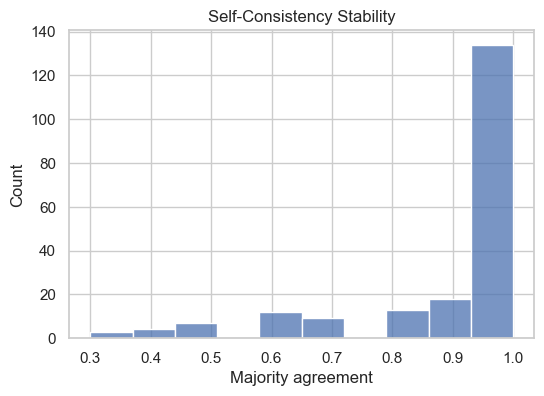

In [75]:
plt.figure(figsize=(6,4))

sns.histplot(sc["consistency"],bins=10)

plt.xlabel("Majority agreement")
plt.ylabel("Count")
plt.title("Self-Consistency Stability")

plt.show()

In [76]:
example = sc.iloc[0]

print("Question:")
print(example["question"])
print()

print("Ground truth:",example["ground_truth"])
print()

print("All predictions:")
print(example["all_predictions"])

Question:
Count the vowels in the string: dgfdsfhuipoai

Ground truth: 5

All predictions:
['5', '5', '5', '5', '5', '5', '5', '5', '5', '5']


In [77]:
pivot = df.pivot_table(
    index=["id","question","model"],
    columns="strategy",
    values="correct"
)

improvements = pivot[
    (pivot["direct"]==False) &
    (pivot["cot"]==True)
]

improvements.head()

,,strategy,cot,direct,self_consistency
id,question,model,,,
1,Count the vowels in the string: dgfdsfhuipoai,gpt-4o-mini,1.0,0.0,1.0
10,Is the number of characters even in the string: d___?%&(5jdfhsd//c§&hdhsadu/a/§_§/hdfjsdfkzeruewr834374/2362364yes,gpt-5.1,1.0,0.0,1.0
100,"I rented a book from the library, the standard renting duration is 4 weeks, but you can expand this twice by two weeks each. I rented a book and expanded it twice, but returned it two weeks before I had to. How many weeks did I have the book?",gpt-4o-mini,1.0,0.0,1.0
11,Is the number of characters even in the string: no,gpt-5.1,1.0,0.0,1.0
14,What number comes next in the following sequence? : 16 8 12 6 10 5,gpt-4o-mini,1.0,0.0,1.0


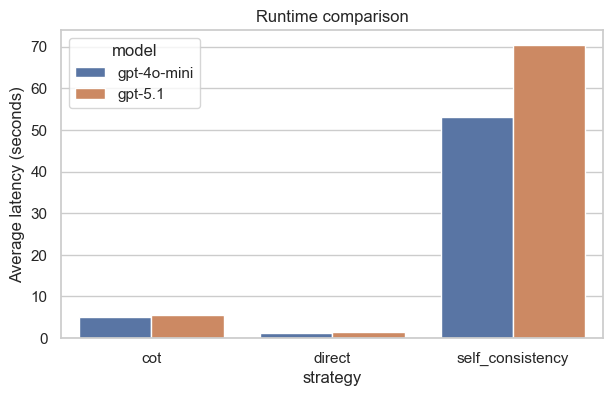

In [78]:
latency = (
    df.groupby(["model","strategy"])
    .latency.mean()
    .reset_index()
)

plt.figure(figsize=(7,4))

sns.barplot(
    data=latency,
    x="strategy",
    y="latency",
    hue="model"
)

plt.ylabel("Average latency (seconds)")
plt.title("Runtime comparison")

plt.show()

In [79]:
task_accuracy = (
    df.groupby(["task_type","model","strategy"])
    .agg(
        tasks=("id","count"),
        accuracy=("correct","mean")
    )
    .reset_index()
)

task_accuracy["accuracy"] = task_accuracy["accuracy"]*100

task_accuracy.sort_values("accuracy")

,task_type,model,strategy,tasks,accuracy
90,isNumberOfCharactersEven,gpt-4o-mini,cot,4,0.0
120,runningTrack,gpt-4o-mini,cot,4,0.0
79,facingDirection2,gpt-4o-mini,direct,4,0.0
145,wordPositions,gpt-4o-mini,direct,4,0.0
26,combineNumbers,gpt-4o-mini,self_consistency,4,0.0
...,...,...,...,...,...
75,facingDirection,gpt-5.1,cot,4,100.0
72,facingDirection,gpt-4o-mini,cot,4,100.0
65,countingInUnsaidWords,gpt-5.1,self_consistency,4,100.0
59,countWords,gpt-5.1,self_consistency,4,100.0


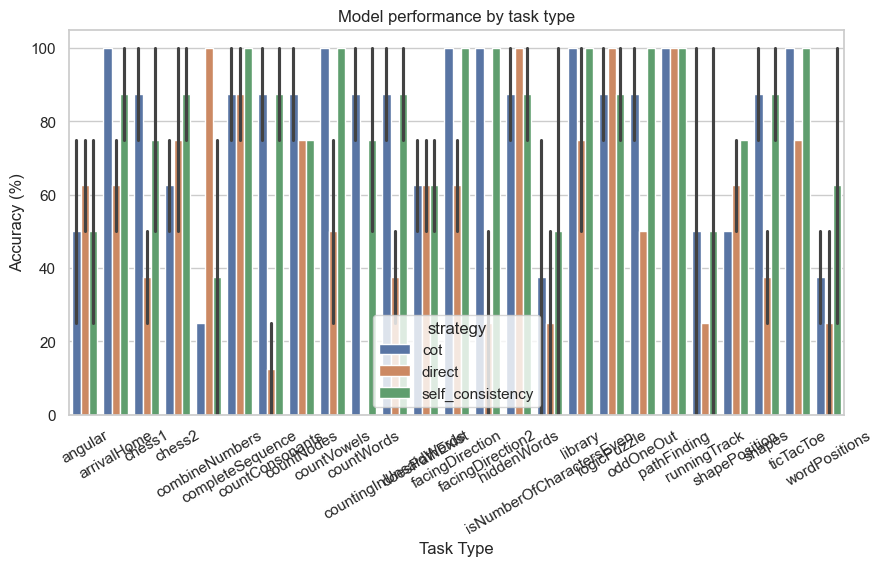

In [80]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=task_accuracy,
    x="task_type",
    y="accuracy",
    hue="strategy"
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Task Type")
plt.title("Model performance by task type")

plt.xticks(rotation=30)

plt.show()

In [81]:
task_difficulty = (
    df.groupby("task_type")
    .correct
    .mean()
    .sort_values()
)

task_difficulty = task_difficulty * 100

task_difficulty

task_type
isNumberOfCharactersEven     37.500000
wordPositions                41.666667
runningTrack                 41.666667
countWords                   54.166667
angular                      54.166667
combineNumbers               54.166667
countConsonants              62.500000
doesPathExist                62.500000
shapePosition                62.500000
chess1                       66.666667
countingInUnsaidWords        70.833333
shapes                       70.833333
chess2                       75.000000
facingDirection2             75.000000
countNodes                   79.166667
oddOneOut                    79.166667
countVowels                  83.333333
arrivalHome                  83.333333
facingDirection              87.500000
completeSequence             91.666667
logicPuzzle                  91.666667
library                      91.666667
ticTacToe                    91.666667
hiddenWords                  91.666667
pathFinding                 100.000000
Name: correct, 

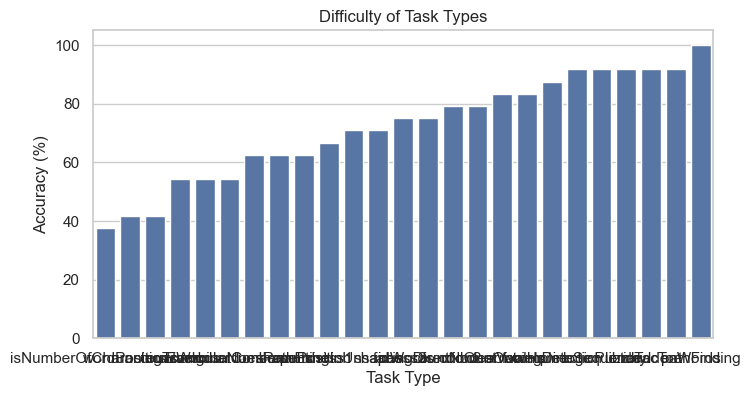

In [82]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=task_difficulty.index,
    y=task_difficulty.values
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Task Type")
plt.title("Difficulty of Task Types")

plt.show()

In [83]:
pivot = df.pivot_table(
    values="correct",
    index="task_type",
    columns="strategy",
    aggfunc="mean"
) * 100

pivot

strategy,cot,direct,self_consistency
task_type,,,
angular,50.0,62.5,50.0
arrivalHome,100.0,62.5,87.5
chess1,87.5,37.5,75.0
chess2,62.5,75.0,87.5
combineNumbers,25.0,100.0,37.5
completeSequence,87.5,87.5,100.0
countConsonants,87.5,12.5,87.5
countNodes,87.5,75.0,75.0
countVowels,100.0,50.0,100.0


<Axes: xlabel='strategy', ylabel='correct'>

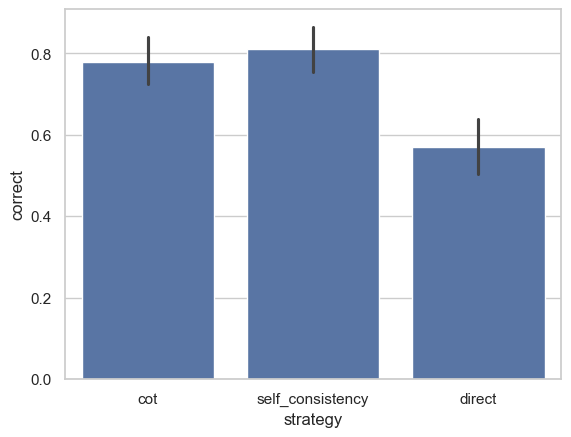

In [84]:
df.groupby("strategy")["correct"].mean()
sns.barplot(data=df, x="strategy", y="correct")

In [85]:
errors = df[df["correct"]==False]

errors["task_type"].value_counts()

task_type
isNumberOfCharactersEven    15
runningTrack                14
wordPositions               14
countWords                  11
angular                     11
combineNumbers              11
shapePosition                9
countConsonants              9
doesPathExist                9
chess1                       8
countingInUnsaidWords        7
shapes                       7
chess2                       6
facingDirection2             6
countNodes                   5
oddOneOut                    5
arrivalHome                  4
countVowels                  4
facingDirection              3
hiddenWords                  2
completeSequence             2
logicPuzzle                  2
ticTacToe                    2
library                      2
Name: count, dtype: int64

In [86]:
df.groupby("question")["correct"].mean().sort_values().head(10)
hard = df.groupby("question")["correct"].mean().sort_values().head(5)

for q in hard.index:
    print(q)

There is a yellow triangle, below it is a red object. To the right of the red object is a blue circle. To the right of the yellow triangle is a green square. What is below the green square?
Give the digit of the position, that the longest word in this string of words is at?
If I run 5 laps around a 400m track and finish 20% of the 6th lap. How many meters did I cover, considering I have to walk back to the starting point in whichever direction around the track is the shortest from where I finished?
How many different numbers can you create by combining the digits 1, 2 and 3. You can use digits more than once
If I run 5 laps around a 400m track and finish 60% of the 6th lap. How many meters did I cover, considering I have to walk back to the starting point in whichever direction around the track is the shortest from where I finished?


In [87]:
pivot = df.pivot_table(
    index=["id","question"],
    columns="strategy",
    values="correct"
)

rescues = pivot[
    (pivot["direct"]==False) &
    (pivot["self_consistency"]==True)
]

rescues

,strategy,cot,direct,self_consistency
id,question,,,
26,"Imagine a bidirectional graph with the nodes (A,B,C,D,E,F,G) and the edges ((A,G),(B,D),(C,D),(C,E),(D,G)). How many nodes, including start and finish do you pass when going from A to E",1.0,0.0,1.0
38,"What does not fit in the group: (14, 2, 200, 5, 10)",0.5,0.0,1.0
39,"What does not fit in the group: (Tom, Mary, Lisa, Luke, Lois)",1.0,0.0,1.0
42,"Imagine a isosceles triangle, with the tip facing up and a circle below it. How many corners do you see?",1.0,0.0,1.0
57,How many words in this sentence have three or less letters?,1.0,0.0,1.0
58,"How many words are in this sentence, including this part after the comma?",0.5,0.0,1.0
6,Count the Consonants in the string: aaathqehsdjqiuw,1.0,0.0,1.0
63,"What word, in this sentence comes in ninth position?",0.5,0.0,1.0
7,Count the Consonants in the string: auibuauioa,1.0,0.0,1.0
